In [1]:
pip install pyzbar

   ---------------------------------------- 0.0/817.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/817.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/817.4 kB ? eta -:--:--
   ------------ --------------------------- 262.1/817.4 kB ? eta -:--:--
   -------------------------------------- - 786.4/817.4 kB 2.4 MB/s eta 0:00:01
   -------------------------------------- - 786.4/817.4 kB 2.4 MB/s eta 0:00:01
   -------------------------------------- - 786.4/817.4 kB 2.4 MB/s eta 0:00:01
   -------------------------------------- - 786.4/817.4 kB 2.4 MB/s eta 0:00:01
   -------------------------------------- - 786.4/817.4 kB 2.4 MB/s eta 0:00:01
   -------------------------------------- - 786.4/817.4 kB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 817.4/817.4 kB 378.7 kB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install pyzbar pillow

Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install Pillow   

Note: you may need to restart the kernel to use updated packages.


In [112]:
from pyzbar.pyzbar import decode
from PIL import Image

In [113]:
img = Image.open("qr_code.jpeg")

In [114]:
decoded_objects = decode(img)

if decoded_objects:
    qr_data = decoded_objects[0].data.decode("utf-8")
    print("QR Content:", qr_data)

# Check if it is a URL
if qr_data.startswith("http"):
    print("URL Found:", qr_data)

# Check if it is a UPI QR
elif qr_data.startswith("upi://"):
    print("UPI Payment QR:", qr_data)
else:
    print("No QR code detected.")

QR Content: upi://pay?pa=atulshahi82106@oksbi&pn=game%20tips%20with%20atul%20shahi&aid=uGICAgMDM09z_cA
UPI Payment QR: upi://pay?pa=atulshahi82106@oksbi&pn=game%20tips%20with%20atul%20shahi&aid=uGICAgMDM09z_cA


In [115]:
from urllib.parse import urlparse, parse_qs
import pandas as pd
import re

upi_link = qr_data

# Parse UPI URL
parsed = urlparse(upi_link)
params = parse_qs(parsed.query)

# Extract UPI ID and Merchant Name
upi_id = params.get("pa", [""])[0]
merchant_name = params.get("pn", [""])[0]

# Feature Extraction
upi_length = len(upi_link)

upi_id_length = len(upi_id)

contains_numbers = 1 if any(char.isdigit() for char in upi_id) else 0

number_count = sum(char.isdigit() for char in upi_id)

if "@" in upi_id:
    bank_handle = upi_id.split("@")[1]
else:
    bank_handle = "unknown"

merchant_name_length = len(merchant_name)

suspicious_words = [
    "loan",
    "cashback",
    "reward",
    "prize",
    "gift",
    "offer",
    "bank",
    "refund"
]

suspicious_keyword_count = 0
for word in suspicious_words:
    if word in merchant_name.lower():
        suspicious_keyword_count += 1

brands = [
    "amazon",
    "flipkart",
    "google",
    "paytm",
    "phonepe",
    "sbi",
    "hdfc",
    "icici"
]

contains_brand_name = 0
for brand in brands:
    if brand in merchant_name.lower():
        contains_brand_name = 1
        break

is_personal_upi = 1 if re.match(r'^[a-zA-Z0-9]+@', upi_id) else 0

# Create DataFrame
f= pd.DataFrame([{
    "UPI_Length": upi_length,
    "UPI_ID_Length": upi_id_length,
    "Contains_Numbers": contains_numbers,
    "Number_Count": number_count,
    "Bank_Handle": bank_handle,
    "Merchant_Name_Length": merchant_name_length,
    "Suspicious_Keyword_Count": suspicious_keyword_count,
    "Contains_Brand_Name": contains_brand_name,
    "Is_Personal_UPI": is_personal_upi
}])

print(f)

   UPI_Length  UPI_ID_Length  Contains_Numbers  Number_Count Bank_Handle  \
0          90             20                 1             5       oksbi   

   Merchant_Name_Length  Suspicious_Keyword_Count  Contains_Brand_Name  \
0                    25                         0                    0   

   Is_Personal_UPI  
0                1  


In [116]:
import pandas as pd
df = pd.read_csv("qr_fraud_detection_dataset_10000.csv")

In [117]:
df.head()

,URL_Length,HTTPS,Domain_Extension,Contains_Login,Contains_Verification,Contains_Brand,Domain_Age_Days,Blacklisted,Fraud
0,54,1,net,0,0,0,2338,0,1
1,57,1,org,1,0,0,3567,0,1
2,54,1,com,0,0,0,2614,0,1
3,54,1,gov,0,0,0,3837,0,1
4,50,1,org,0,0,1,1545,0,1


In [118]:
df.shape

(10000, 9)

In [119]:
df.info

<bound method DataFrame.info of       URL_Length  HTTPS Domain_Extension  Contains_Login  \
0             54      1              net               0   
1             57      1              org               1   
2             54      1              com               0   
3             54      1              gov               0   
4             50      1              org               0   
...          ...    ...              ...             ...   
9995          46      1              edu               0   
9996          10      1              org               0   
9997          10      1              org               0   
9998          71      1              gov               0   
9999          37      1              edu               0   

      Contains_Verification  Contains_Brand  Domain_Age_Days  Blacklisted  \
0                         0               0             2338            0   
1                         0               0             3567            0   
2               

In [120]:
df.isnull().sum()

URL_Length               0
HTTPS                    0
Domain_Extension         0
Contains_Login           0
Contains_Verification    0
Contains_Brand           0
Domain_Age_Days          0
Blacklisted              0
Fraud                    0
dtype: int64

In [121]:
df.duplicated().sum()

np.int64(6)

In [122]:
df["Fraud"].value_counts()

Fraud
1    9000
0    1000
Name: count, dtype: int64

In [123]:
df["Fraud"].value_counts(normalize=True)*100

Fraud
1    90.0
0    10.0
Name: proportion, dtype: float64

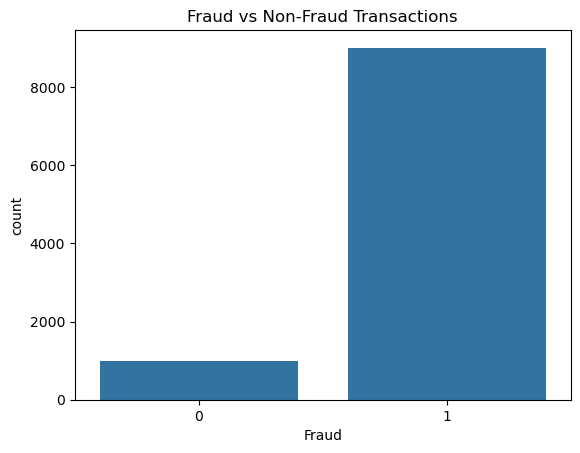

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Fraud', data=df)

plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

In [125]:
x = df.drop('Fraud', axis=1)
y = df['Fraud']

In [126]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
x_train = pd.get_dummies(x_train)
x_test = pd.get_dummies(x_test)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 17)
(2000, 17)
(8000,)
(2000,)


In [127]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [128]:
from sklearn.metrics import classification_report
y_pred = rf.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00      1800

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [129]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 200    0]
 [   0 1800]]


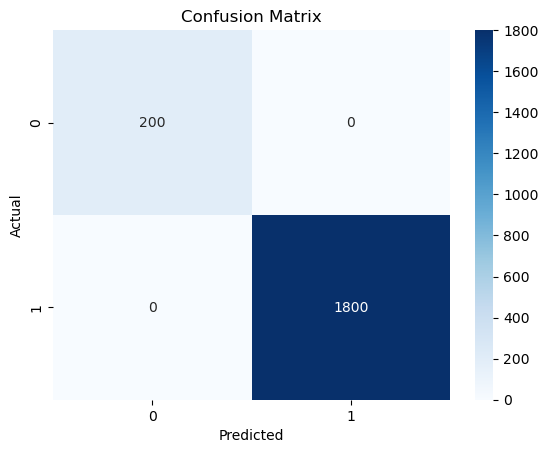

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [131]:
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf.feature_importances_
})
importance = importance.sort_values(by='Importance', ascending=False)
print(importance.head(10))

                   Feature  Importance
5          Domain_Age_Days    0.388900
0               URL_Length    0.242245
1                    HTTPS    0.154054
6              Blacklisted    0.121905
11   Domain_Extension_info    0.023215
7   Domain_Extension_click    0.019481
14   Domain_Extension_site    0.018203
16    Domain_Extension_xyz    0.014289
15    Domain_Extension_top    0.013969
3    Contains_Verification    0.002432


In [133]:
f = f.reindex(columns=x_train.columns, fill_value=0)

test = rf.predict(f)
print(test)

[0]
